# Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

# Modeling Daily Rat Sightings in Manhattan

## Importing the Data

In [2]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to MANHATTAN

rs = rs[rs['borough']=='MANHATTAN']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

rs

,created_date,count
2,2020-01-01,4
7,2020-01-02,7
12,2020-01-03,16
17,2020-01-04,10
21,2020-01-05,5
...,...,...
8905,2025-02-24,19
8910,2025-02-25,20
8915,2025-02-26,15
8920,2025-02-27,16


In [3]:
## There are 2251 days from 2020-01-01 to 2025-02-28 inclusive. So if this number is <2251, we must make sure to add in 0's.

len(rs)

1886

In [4]:
## We find the missing row and add it in.
## There's probably a better way to find in the missing dates and update it. This is a sort of hacky solution.

date_range = pd.date_range(start=rs['created_date'].min(), end=rs['created_date'].max(), freq='D')
complete_dates_df = pd.DataFrame(date_range, columns=['created_date'])
rs = pd.merge(complete_dates_df, rs, on='created_date', how='left')
rs['count'] = rs['count'].fillna(0).astype(int)
rs = rs.sort_values(by='created_date').reset_index(drop=True)

rs

,created_date,count
0,2020-01-01,4
1,2020-01-02,7
2,2020-01-03,16
3,2020-01-04,10
4,2020-01-05,5
...,...,...
1881,2025-02-24,19
1882,2025-02-25,20
1883,2025-02-26,15
1884,2025-02-27,16


## Baseline Seasonal Average Model

In [5]:
years_back_use = 4
day_window_use = 4

In [6]:
def seasonal_average_forecast(data, target_dates, years_back=years_back_use, day_window=day_window_use):
    df = data.copy()
    # ensure datetime type
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["doy"] = df["created_date"].dt.dayofyear
    df["year"] = df["created_date"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["doy"] - target_doy) <= day_window))
        forecasts.append(df.loc[mask, "count"].mean())
    return pd.Series(forecasts, index=target_dates)

In [7]:
results = []

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
baseline_results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
baseline_results_df.loc["mean"] = ["mean", baseline_results_df["rmse"].mean(), baseline_results_df["mape"].mean()]

baseline_results_df

,fold,rmse,mape
0,0,4.002548,0.280540
1,1,3.973568,0.238817
2,2,5.476119,0.543911
3,3,5.317748,0.319481
4,4,5.362828,0.521556
5,5,6.716653,0.400610
6,6,6.795952,0.362424
7,7,5.487635,0.328791
8,8,6.554118,0.492396
9,9,5.527818,0.276961


## Baseline Year Ago Rolling 4 Week Average 

In [8]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

## Just saving a copy for later
rs_saved = rs.copy()

In [9]:
# Tired of writing np.sqrt or typing a long name.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    # Calculate the 4-week rolling average for the training data
    train_sorted = train.sort_values('ds') # making sure to sort it by date
    train_sorted['rolling_4w'] = train_sorted['y'].rolling(window=4, min_periods=1).mean()

    # This part of the code makes the predictions. We use the 'rolling_4w' column of the training set.
    y_pred = []
    y_true = test['y'].values

    for idx, row in test.iterrows():
        # Predict using the latest rolling average from the train data
        prediction = train_sorted['rolling_4w'].iloc[-1]  # Last value in the train rolling avg
        y_pred.append(prediction)
        
    # Calculate RMSE and MAPE for this fold
    fold_rmse = rmse(y_true, y_pred)
    fold_mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': fold, 'rmse': fold_rmse, 'mape': fold_mape})

rolling4w_results_df = pd.DataFrame(results)

# Optional: add a row for the overall average RMSE and MAPE
overall_rmse = rolling4w_results_df['rmse'].mean()
overall_mape = rolling4w_results_df['mape'].mean()
rolling4w_results_df.loc['mean'] = ['mean', overall_rmse, overall_mape]

In [10]:
rolling4w_results_df

,fold,rmse,mape
0,0,3.615443,0.240564
1,1,4.228939,0.291261
2,2,5.489438,0.553228
3,3,7.294200,0.306979
4,4,6.184658,0.560685
5,5,7.215435,0.457943
6,6,7.551608,0.438976
7,7,5.195293,0.290578
8,8,5.712611,0.416645
9,9,6.058495,0.281693


## Prophet Model

In [11]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

In [12]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)

09:00:02 - cmdstanpy - INFO - Chain [1] start processing
09:00:02 - cmdstanpy - INFO - Chain [1] done processing
09:00:03 - cmdstanpy - INFO - Chain [1] start processing
09:00:03 - cmdstanpy - INFO - Chain [1] done processing
09:00:03 - cmdstanpy - INFO - Chain [1] start processing
09:00:03 - cmdstanpy - INFO - Chain [1] done processing
09:00:04 - cmdstanpy - INFO - Chain [1] start processing
09:00:04 - cmdstanpy - INFO - Chain [1] done processing
09:00:05 - cmdstanpy - INFO - Chain [1] start processing
09:00:05 - cmdstanpy - INFO - Chain [1] done processing
09:00:05 - cmdstanpy - INFO - Chain [1] start processing
09:00:05 - cmdstanpy - INFO - Chain [1] done processing
09:00:06 - cmdstanpy - INFO - Chain [1] start processing
09:00:06 - cmdstanpy - INFO - Chain [1] done processing
09:00:06 - cmdstanpy - INFO - Chain [1] start processing
09:00:07 - cmdstanpy - INFO - Chain [1] done processing
09:00:07 - cmdstanpy - INFO - Chain [1] start processing
09:00:07 - cmdstanpy - INFO - Chain [1]

In [13]:
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

In [14]:
prophet_results_df

,fold,rmse,mape
0,0,2.630258,0.166977
1,1,3.878704,0.221130
2,2,4.443830,0.398059
3,3,5.234971,0.294034
4,4,4.960688,0.406914
5,5,5.533058,0.267577
6,6,5.525601,0.214717
7,7,3.866932,0.195053
8,8,3.747846,0.269057
9,9,4.545198,0.175069


## SARIMA Model with auto_arima parameters.

In [15]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [16]:
from pmdarima import auto_arima

In [17]:
def fourier_terms(df, period, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for i in range(1, n_terms + 1):
        fourier_df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        fourier_df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

In [18]:
# Number of Fourier terms and period (365 for yearly seasonality)
n_terms = 5  # Number of terms for Fourier Terms
period = 365 

In [19]:
# Generate Fourier terms and putting it into a list
fourier_train = fourier_terms(rs, period, n_terms)

# Name it exog since it will serve as exogenous features for SARIMAX. This is the X.
exog = fourier_train

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Make sure the columns for SARIMA model are renamed.
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

results = []

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    orders = (2,1,3)
    seasonal_orders = (0,0,0,0)

    # model_auto = auto_arima(train['y'], 
    #                         exog=exog_train,  # Exogenous Fourier terms for training data
    #                         seasonal=True, 
    #                         # m=7,  # we choose 7 since we can at least model weekly seasonality. yearly seasonality would not be able to run.
    #                         trace=True, 
    #                         stepwise=True,  # stepwise search to speed up
    #                         suppress_warnings=True, 
    #                         # n_jobs=-1,  # use all available cores for parallel processing
    #                         maxiter=100,  # limit the number of iterations (really important for run time)
    #                         max_p=3, 
    #                         max_q=3, 
    #                         max_P=2, 
    #                         max_Q=2, 
    #                         max_d=2, 
    #                         max_D=1)
    # orders = model_auto.order  # (p, d, q)
    # seasonal_orders = model_auto.seasonal_order  # (P, D, Q, s)
    
    # Fit the SARIMAX model with the exogenous features (Fourier terms)
    model_sarimax = SARIMAX(train['y'], 
                            order=orders,  
                            seasonal_order=seasonal_orders,  
                            exog=exog_train,  # Exogenous Fourier terms for training data
                            enforce_stationarity=False,
                            enforce_invertibility=False)
    
    model_fit = model_sarimax.fit(disp=False)
    
    # Predict for the test period. Have to remember to subtract 1 to get the correct index.
    y_pred = model_fit.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test, dynamic=False)
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

sarima_results_df = pd.DataFrame(results)

In [21]:
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]

In [22]:
sarima_results_df

,fold,rmse,mape
0,0,3.410279,0.200572
1,1,3.597951,0.201622
2,2,4.911366,0.479573
3,3,6.122912,0.276266
4,4,5.529393,0.512551
5,5,6.135404,0.361464
6,6,6.560471,0.328646
7,7,4.711990,0.256146
8,8,5.473475,0.399498
9,9,5.057201,0.201814


## Holt-Winters Model

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [24]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # First we fit the Holt-Winters Exponential Smoothing Model to the training data
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=365).fit(optimized=True)
    
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

hw_results_df = pd.DataFrame(results)

In [25]:
hw_results_df.loc['mean'] = ['mean',  hw_results_df['rmse'].mean(), hw_results_df['mape'].mean()]

In [26]:
hw_results_df

,fold,rmse,mape
0,0,5.527342,0.406834
1,1,5.092634,0.282056
2,2,6.192805,0.585478
3,3,5.475992,0.268360
4,4,6.721850,0.492479
5,5,8.392364,0.421627
6,6,8.923703,0.435096
7,7,6.506062,0.338642
8,8,8.500149,0.616871
9,9,7.029098,0.335181


## XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs is quite bare. We will need to add features for use.

In [27]:
import xgboost as xgb
from xgboost import plot_importance

### Adding Features to XGBoost

In [28]:
def create_features(df):
    # create time series features based on time series index.
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    # features to handly cyclic behavior
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['lag15'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag17'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag18'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag19'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['lag20'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag21'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag22'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag23'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag24'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    # these are lags on the target itself
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df, forecast_horizon_days=14):
    df = df.copy()
    df = df.sort_index()

    # Moving averages (using previous values only)
    df['ma7'] = df['y'].shift(forecast_horizon_days).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(forecast_horizon_days).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(forecast_horizon_days).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(forecast_horizon_days).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(forecast_horizon_days).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(forecast_horizon_days).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(forecast_horizon_days).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(forecast_horizon_days).rolling(window=365).mean()
    
    return df

def add_moving_averages_shifted(df, forecast_horizon_days=14):
    """
    Adds moving averages shifted so that only data before the forecast horizon is used.
    
    Parameters:
    - df: DataFrame with 'y' and datetime index
    - forecast_horizon_days: int, how many days ahead we're forecasting (14 weeks = 98)
    """
    df = df.copy()
    df = df.sort_index()
    
    # shift by forecast horizon + 1 so we never peek into future
    shift_amount = forecast_horizon_days
    
    df['ma7'] = df['y'].shift(shift_amount).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(shift_amount).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(shift_amount).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(shift_amount).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(shift_amount).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(shift_amount).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(shift_amount).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(shift_amount).rolling(window=365).mean()
    
    return df

def add_lagged_differences_shifted(df, forecast_horizon_days=14, lag_list=None):
    """
    Add lagged differences with shift to prevent using future information in cross validation.
    Detects trends and changes in trend without peeking into the future. Our data exhibits changes in trend.

    - forecast_horizon_days: int, how many days ahead we're forecasting (2 weeks = 14)
    - lag_list: list of int, lags in days to compute differences and percent changes
    """
    df = df.copy()
    
    if lag_list is None:
        lag_list = [1, 7, 30, 60, 90, 365]  # default lags

    # Shift all computations by the forecast horizon
    shift_amount = forecast_horizon_days
    
    # Simple differences and percent changes
    for lag in lag_list:
        df[f'y_diff_{lag}'] = df['y'].shift(shift_amount) - df['y'].shift(shift_amount + lag)
        df[f'y_pct_change_{lag}'] = (df['y'].shift(shift_amount) - df['y'].shift(shift_amount + lag)) / df['y'].shift(shift_amount + lag)

    # Differences between successive lag differences to detect trend acceleration
    for i in range(1, len(lag_list)):
        lag_prev = lag_list[i-1]
        lag_curr = lag_list[i]
        df[f'y_diff_lag{lag_prev}_{lag_curr}'] = df[f'y_diff_{lag_curr}'] - df[f'y_diff_{lag_prev}']
    
    return df

In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Manhattan and hope that it is representative of the average weather over the whole city.

In [29]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [30]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index 
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary columns
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [31]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [32]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [33]:
# This must be run after importing weather data

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df

In [34]:
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)

In [35]:
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

In [36]:
rs = add_lagged_differences_shifted(rs)

### Features for XGBoost

In [37]:
FEATURES = ['apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'temperature_2m_max_lag30',
            'temperature_2m_max_lag60',
            'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag30', 'lag60',
            'dayofweek', 'month', 'dayofyear', 'dayofmonth', 'weekofyear', 'is_federal_holiday', 'Trash_Law'
            ]


#must be very careful here -- we are trying to forecast 14 days out so

rs.columns

Index(['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       ...
       'y_pct_change_60', 'y_diff_90', 'y_pct_change_90', 'y_diff_365',
       'y_pct_change_365', 'y_diff_lag1_7', 'y_diff_lag7_30',
       'y_diff_lag30_60', 'y_diff_lag60_90', 'y_diff_lag90_365'],
      dtype='object', length=117)

### Add default parameters for XGBoost

In [38]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
        # 'base_score': 0.5, 
         'n_estimators': 500, 
        # 'min_child_weight': 7, 
         'learning_rate': 0.1,
        #  'max_depth': 8, 
        #  'subsample': 1,
        #  'colsample_bytree': 0.96,
        #  'colsample_bylevel': 0.6, 
        #  'colsample_bynode': 0.9, 
        #  'reg_alpha': 2.2, 
        #  'gamma': 100, 
        #  'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }

## uncomment to use GPU
params.update({
    "tree_method": "hist",
    "device": "cuda"
})


### Results for XGBoost Model

In [39]:
print(FEATURES)
print(params)
TARGET = 'y'

# Gotta make sure the features and parameters exist.

TARGET = "y"

rs = rs.replace([np.inf, -np.inf], np.nan)
rs = rs.fillna(0)

reg = xgb.XGBRegressor(**params)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    reg.fit(train[FEATURES], train[TARGET])
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    
    # Our metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})
    print(results)

xgb_results_df = pd.DataFrame(results)
mean_rmse = xgb_results_df['rmse'].mean()
mean_mape = xgb_results_df['mape'].mean()
xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

['apparent_temperature_min_lag30', 'apparent_temperature_min_lag60', 'temperature_2m_max_lag30', 'temperature_2m_max_lag60', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag30', 'lag60', 'dayofweek', 'month', 'dayofyear', 'dayofmonth', 'weekofyear', 'is_federal_holiday', 'Trash_Law']
{'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'booster': 'gbtree', 'n_estimators': 500, 'learning_rate': 0.1, 'tree_method': 'hist', 'device': 'cuda'}


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:02:52] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[{'fold': 0, 'rmse': 3.955799268746363, 'mape': 0.27576345205307007}]


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:02:53] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[{'fold': 0, 'rmse': 3.955799268746363, 'mape': 0.27576345205307007}, {'fold': 1, 'rmse': 3.5104949821693845, 'mape': 0.24346284568309784}]


...

[{'fold': 0, 'rmse': 3.955799268746363, 'mape': 0.27576345205307007}, {'fold': 1, 'rmse': 3.5104949821693845, 'mape': 0.24346284568309784}, {'fold': 2, 'rmse': 4.531351653964813, 'mape': 0.40989917516708374}, {'fold': 3, 'rmse': 5.638107287395274, 'mape': 0.2671511769294739}, {'fold': 4, 'rmse': 7.745736703035671, 'mape': 0.6242416501045227}, {'fold': 5, 'rmse': 5.267300755118607, 'mape': 0.22446119785308838}, {'fold': 6, 'rmse': 5.771521388417693, 'mape': 0.32409706711769104}, {'fold': 7, 'rmse': 5.332011575627622, 'mape': 0.2785463035106659}, {'fold': 8, 'rmse': 5.325086874096497, 'mape': 0.37882232666015625}, {'fold': 9, 'rmse': 4.323528617226847, 'mape': 0.18060588836669922}, {'fold': 10, 'rmse': 5.670533413024953, 'mape': 0.20777498185634613}, {'fold': 11, 'rmse': 6.568167137760773, 'mape': 0.3410632610321045}, {'fold': 12, 'rmse': 5.216254819917589, 'mape': 0.16852299869060516}, {'fold': 13, 'rmse': 5.607903332637609, 'mape': 0.2588653564453125}, {'fold': 14, 'rmse': 5.1813660170

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:03:10] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[{'fold': 0, 'rmse': 3.955799268746363, 'mape': 0.27576345205307007}, {'fold': 1, 'rmse': 3.5104949821693845, 'mape': 0.24346284568309784}, {'fold': 2, 'rmse': 4.531351653964813, 'mape': 0.40989917516708374}, {'fold': 3, 'rmse': 5.638107287395274, 'mape': 0.2671511769294739}, {'fold': 4, 'rmse': 7.745736703035671, 'mape': 0.6242416501045227}, {'fold': 5, 'rmse': 5.267300755118607, 'mape': 0.22446119785308838}, {'fold': 6, 'rmse': 5.771521388417693, 'mape': 0.32409706711769104}, {'fold': 7, 'rmse': 5.332011575627622, 'mape': 0.2785463035106659}, {'fold': 8, 'rmse': 5.325086874096497, 'mape': 0.37882232666015625}, {'fold': 9, 'rmse': 4.323528617226847, 'mape': 0.18060588836669922}, {'fold': 10, 'rmse': 5.670533413024953, 'mape': 0.20777498185634613}, {'fold': 11, 'rmse': 6.568167137760773, 'mape': 0.3410632610321045}, {'fold': 12, 'rmse': 5.216254819917589, 'mape': 0.16852299869060516}, {'fold': 13, 'rmse': 5.607903332637609, 'mape': 0.2588653564453125}, {'fold': 14, 'rmse': 5.1813660170

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:03:11] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


[{'fold': 0, 'rmse': 3.955799268746363, 'mape': 0.27576345205307007}, {'fold': 1, 'rmse': 3.5104949821693845, 'mape': 0.24346284568309784}, {'fold': 2, 'rmse': 4.531351653964813, 'mape': 0.40989917516708374}, {'fold': 3, 'rmse': 5.638107287395274, 'mape': 0.2671511769294739}, {'fold': 4, 'rmse': 7.745736703035671, 'mape': 0.6242416501045227}, {'fold': 5, 'rmse': 5.267300755118607, 'mape': 0.22446119785308838}, {'fold': 6, 'rmse': 5.771521388417693, 'mape': 0.32409706711769104}, {'fold': 7, 'rmse': 5.332011575627622, 'mape': 0.2785463035106659}, {'fold': 8, 'rmse': 5.325086874096497, 'mape': 0.37882232666015625}, {'fold': 9, 'rmse': 4.323528617226847, 'mape': 0.18060588836669922}, {'fold': 10, 'rmse': 5.670533413024953, 'mape': 0.20777498185634613}, {'fold': 11, 'rmse': 6.568167137760773, 'mape': 0.3410632610321045}, {'fold': 12, 'rmse': 5.216254819917589, 'mape': 0.16852299869060516}, {'fold': 13, 'rmse': 5.607903332637609, 'mape': 0.2588653564453125}, {'fold': 14, 'rmse': 5.1813660170

In [40]:
xgb_results_df

,fold,rmse,mape
0,0,3.955799,0.275763
1,1,3.510495,0.243463
2,2,4.531352,0.409899
3,3,5.638107,0.267151
4,4,7.745737,0.624242
5,5,5.267301,0.224461
6,6,5.771521,0.324097
7,7,5.332012,0.278546
8,8,5.325087,0.378822
9,9,4.323529,0.180606


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:03:11] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


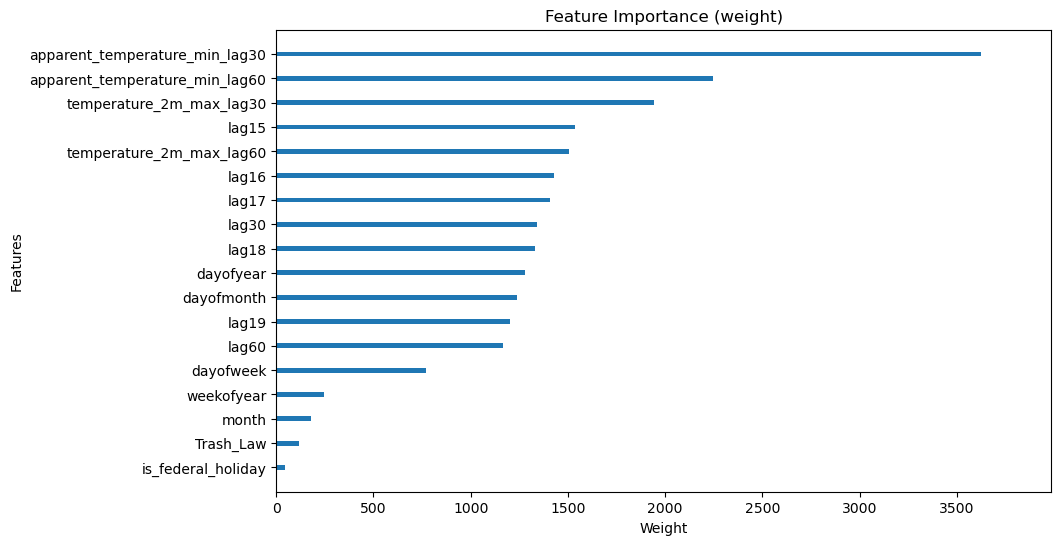

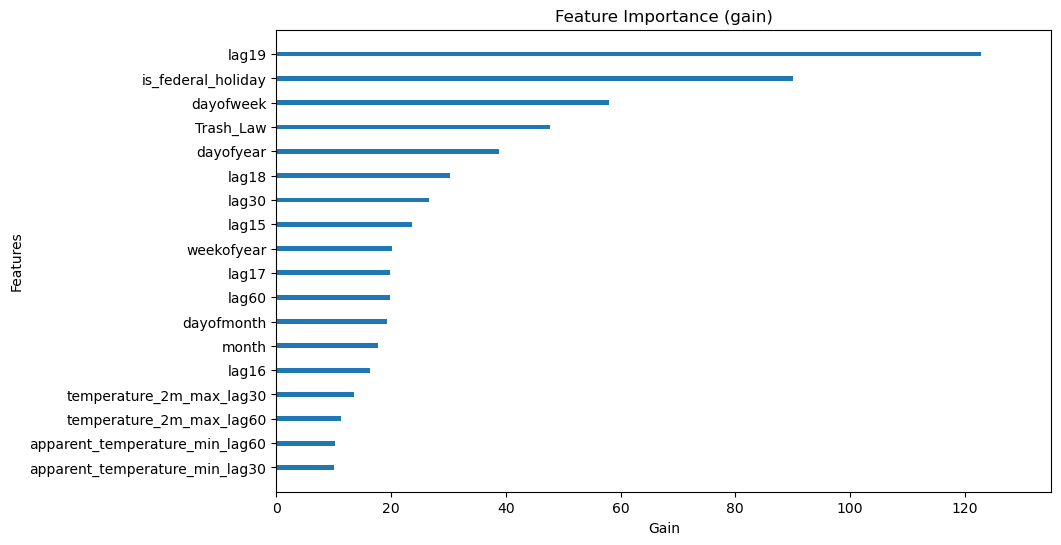

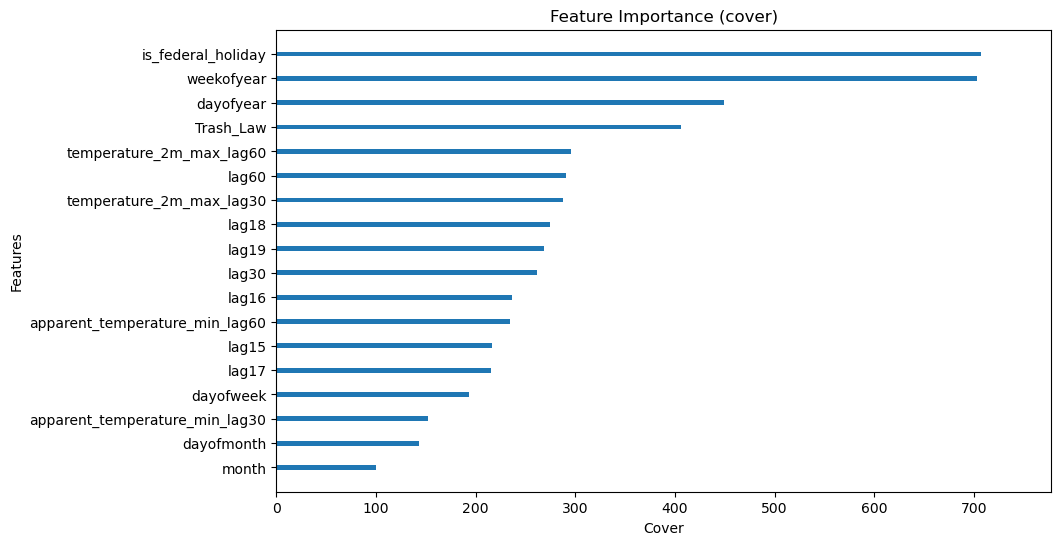

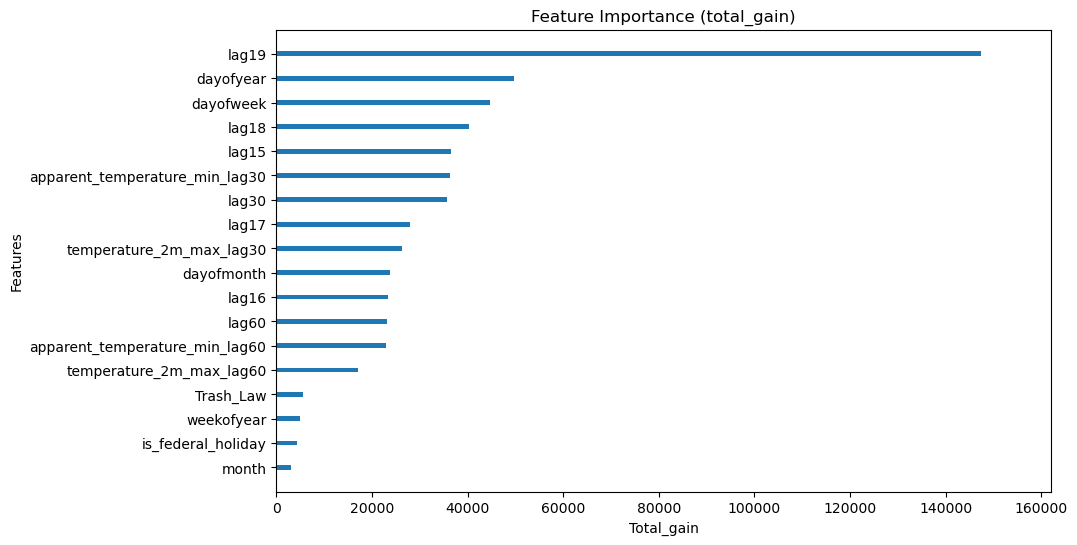

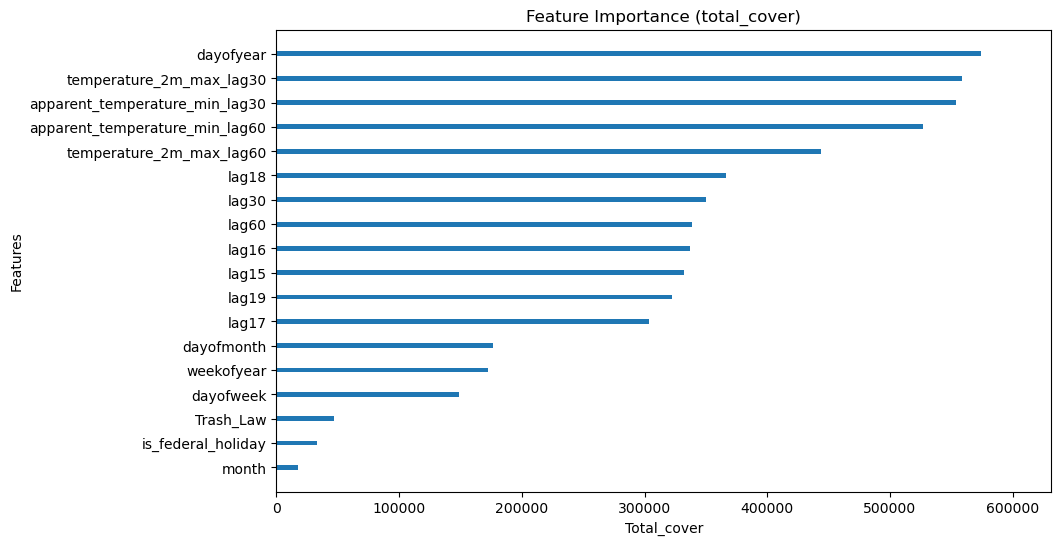

In [ ]:
# model = reg.fit(train[FEATURES], train[TARGET])
# importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']
# for importance_type in importance_types:
#     fig, ax = plt.subplots(figsize=(10, 6))
#     xgb.plot_importance(model, ax=ax, importance_type=importance_type, grid=False, show_values=False)
#     plt.xlabel(f'{importance_type}'.capitalize())
#     plt.title(f'Feature Importance ({importance_type})')
#     plt.show()

## XGBoosted Prophet Model

In [42]:
# Recall the copy that was saved.
rs_saved

,ds,y
0,2020-01-01,4
1,2020-01-02,7
2,2020-01-03,16
3,2020-01-04,10
4,2020-01-05,5
...,...,...
1881,2025-02-24,19
1882,2025-02-25,20
1883,2025-02-26,15
1884,2025-02-27,16


In [43]:
rs = rs_saved

In [44]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Split the dataset into training and testing sets
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # Fit Prophet on the training data
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Make predictions on the training set to calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
    train_forecast = model.predict(train_future)
    
    # Calculate residuals (actual - predicted) on the training data
    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    
    # Build a new DataFrame of residuals
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })

    train = train.set_index('ds')
    train.index = pd.to_datetime(train.index)
    train = create_features(train)
    train = add_cyclic(train)
    train = add_lags(train)
    train = add_seasonal_lags(train)
    train = add_moving_averages(train)
    train = add_weather_data(train,wd)
    train = add_more_weather_feature(train)
    train = add_federal_holidays(train, custom_holidays = ['12-31'])
    train = add_law_flag(train, law_name='Trash_Law', start_date = '2024-03-01')
    train = add_law_flag(train, law_name = 'New_Trash_Law', start_date = '2024-11-01')
    train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
    train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']
    
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train_residuals, y_train_residuals)
    

    test = test.set_index('ds')
    test.index = pd.to_datetime(test.index)
    test = create_features(test)
    test = add_cyclic(test)
    test = add_lags(test)
    test = add_seasonal_lags(test)
    test = add_moving_averages(test)
    test = add_weather_data(test,wd)
    test = add_more_weather_feature(test)
    test = add_federal_holidays(test, custom_holidays = ['12-31'])
    test = add_law_flag(test, law_name='Trash_Law', start_date = '2024-03-01')
    test = add_law_flag(test, law_name = 'New_Trash_Law', start_date = '2024-11-01')
    test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
    test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

    # Predict residuals using XGBoost for the test set
    X_test = test[FEATURES]  # Features for the test set
    xgb_residual_preds = xgb_model.predict(X_test)
    
    # Forecast using Prophet on the test set
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)
    
    # Combine Prophet's forecast and XGBoost's residual prediction
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    
    # Actual values for the test set
    y_true = test['y'].values
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Store the results for this fold
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

    ## Uncomment code below if you want to have plots on feature importance.
    # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
    # plot_importance(xgb_model, ax=ax1, importance_type='gain')
    # ax1.set_title('Gain-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax2, importance_type='weight')
    # ax2.set_title('Split-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax3, importance_type='cover')
    # ax3.set_title('Cover Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
    # ax4.set_title('Total Gain Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
    # ax5.set_title('Total Cover Importance', fontsize=12)

    plt.show()

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results)

prophet_xgb_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_results_df['rmse'].mean()
mean_mape = prophet_xgb_results_df['mape'].mean()
prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

09:03:13 - cmdstanpy - INFO - Chain [1] start processing
09:03:13 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:03:13] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)
09:03:15 - cmdstanpy - INFO - Chain [1] start processing
09:03:15 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:03:15] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)
09:03:16 - cmdstanpy - INFO - Chain [1] start processing
09:03:16 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/cor

In [45]:
prophet_xgb_results_df

,fold,rmse,mape
0,0,2.903263,0.198593
1,1,5.468936,0.368195
2,2,5.895304,0.556283
3,3,5.884668,0.333935
4,4,6.591636,0.637341
5,5,6.006714,0.318957
6,6,6.558491,0.357906
7,7,5.256147,0.267546
8,8,6.277855,0.442343
9,9,4.870505,0.236024


# Conclusions on Model Comparisons

## Results Table

In [46]:
# We make a dictionary of models and their results to make it easier to iterate over.
models = {
    'baseline': baseline_results_df,
    'rolling4w': rolling4w_results_df,
    'prophet': prophet_results_df,
    'sarima': sarima_results_df,
    'hw': hw_results_df,
    'xgb': xgb_results_df,
    'prophet+xgb': prophet_xgb_results_df
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

# Put all of the dataframes together into one dataframe for display
final_results_df = pd.concat(all_results, ignore_index=True)

# Make a pivot table so that we display rmse, mape and then each of the models and their results.
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                                \
model  baseline        hw   prophet prophet+xgb rolling4w    sarima       xgb   
fold                                                                            
0      4.002548  5.527342  2.630258    2.903263  3.615443  3.410279  3.955799   
1      3.973568  5.092634  3.878704    5.468936  4.228939  3.597951  3.510495   
2      5.476119  6.192805  4.443830    5.895304  5.489438  4.911366  4.531352   
3      5.317748  5.475992  5.234971    5.884668  7.294200  6.122912  5.638107   
4      5.362828  6.721850  4.960688    6.591636  6.184658  5.529393  7.745737   
5      6.716653  8.392364  5.533058    6.006714  7.215435  6.135404  5.267301   
6      6.795952  8.923703  5.525601    6.558491  7.551608  6.560471  5.771521   
7      5.487635  6.506062  3.866932    5.256147  5.195293  4.711990  5.332012   
8      6.554118  8.500149  3.747846    6.277855  5.712611  5.473475  5.325087   
9      5.527818  7.029098  4.545198    4.870505  6.058495  5.057201  4.323529   
10     5.623782  7.856336  5.646744    4.747299  5.354404  5.146523  5.670533   
11     6.075183  6.568933  5.003419    5.343762  5.087625  6.317788  6.568167   
12     5.326969  6.747581  4.994729    4.552380  5.291503  4.712784  5.216255   
13     4.265165  5.579357  3.892640    3.828593  5.021383  3.979941  5.607903   
14     6.462533  6.181776  5.421970    4.655412  6.152090  6.008177  5.181366   
15     6.311571  8.215867  5.529000    4.570032  7.047669  5.756181  5.772665   
16     5.309839  6.738746  6.188396    5.629172  5.656065  5.060737  5.035966   
17     5.684011  6.053501  4.959302    6.006379  6.640649  4.927510  6.067361   
18     3.431419  4.097466  4.278606    3.059076  2.297126  2.999647  3.046327   
19     4.305684  4.339167  3.118962    4.565811  5.246598  3.497015  4.066345   
20     4.474926  4.824830  3.872575    3.765460  3.977616  3.448473  4.428167   
21     4.060794  3.422410  4.140474    6.047337  5.548488  4.733797  5.404820   
22     4.660300  4.701978  3.883652    3.556550  3.384576  4.307955  3.999896   
23     7.468519  8.091252  6.990533    5.895511  7.208006  7.468267  7.160141   
24     4.362053  5.941912  3.114453    3.623907  8.415016  4.387494  4.926514   
25     5.008095  5.665672  3.604379    4.690312  5.315073  4.409397  3.654625   
mean   5.309455  6.284184  4.577189    5.009635  5.622693  4.948928  5.123384   

           mape                                                                
model  baseline        hw   prophet prophet+xgb rolling4w    sarima       xgb  
fold                                                                           
0      0.280540  0.406834  0.166977    0.198593  0.240564  0.200572  0.275763  
1      0.238817  0.282056  0.221130    0.368195  0.291261  0.201622  0.243463  
2      0.543911  0.585478  0.398059    0.556283  0.553228  0.479573  0.409899  
3      0.319481  0.268360  0.294034    0.333935  0.306979  0.276266  0.267151  
4      0.521556  0.492479  0.406914    0.637341  0.560685  0.512551  0.624242  
5      0.400610  0.421627  0.267577    0.318957  0.457943  0.361464  0.224461  
6      0.362424  0.435096  0.214717    0.357906  0.438976  0.328646  0.324097  
7      0.328791  0.338642  0.195053    0.267546  0.290578  0.256146  0.278546  
8      0.492396  0.616871  0.269057    0.442343  0.416645  0.399498  0.378822  
9      0.276961  0.335181  0.175069    0.236024  0.281693  0.201814  0.180606  
10     0.192254  0.279952  0.205682    0.176682  0.196827  0.158722  0.207775  
11     0.339792  0.338217  0.228078    0.264528  0.270098  0.347380  0.341063  
12     0.242283  0.265265  0.172053    0.196670  0.235474  0.182833  0.168523  
13     0.214755  0.264291  0.175412    0.176459  0.265180  0.188126  0.258865  
14     0.382883  0.383868  0.253289    0.278623  0.320797  0.298294  0.283423  
15     0.328794  0.366886  0.190916    0.241045  0.406757  0.268151  0.264742  
16     0.334273  0.418009  0.297578    0.307951  0.379940  0

## Summary

In the above table, we see that the Prophet model had the best average RMSE, but the margins are quite slim so far. Prophet beat out Sarima by at best 0.2 on average.

In [47]:
# We export the final table to save for later.
# Set a title 
#final_table = final_table.style.set_caption('Manhattan: Comparison of Models using Walk-Forward Validation with 23 folds and 14 Day Test Sizes')
#final_table.to_csv('manhattan_comparison_results.csv', index=True)

# Neural Prophet

In [49]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [50]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to MANHATTAN

rs = rs[rs['borough']=='MANHATTAN']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

## rename columns for prophet

rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [51]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

def add_weather_data_no_index(df,wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])

    for column in wd.columns:
        df[column] = wd[column].values

    return df

In [52]:
regressed_features = ['apparent_temperature_max', 
    #'apparent_temperature_min', 
    #'apparent_temperature_mean', 
    #'snowfall_sum'
    ]
wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

rs

,ds,y,apparent_temperature_max
0,2020-01-01,4,-0.3
1,2020-01-02,7,4.5
2,2020-01-03,16,7.3
3,2020-01-04,10,7.9
4,2020-01-05,5,-1.0
...,...,...,...
1881,2025-02-24,19,4.0
1882,2025-02-25,20,9.8
1883,2025-02-26,15,8.4
1884,2025-02-27,16,9.9


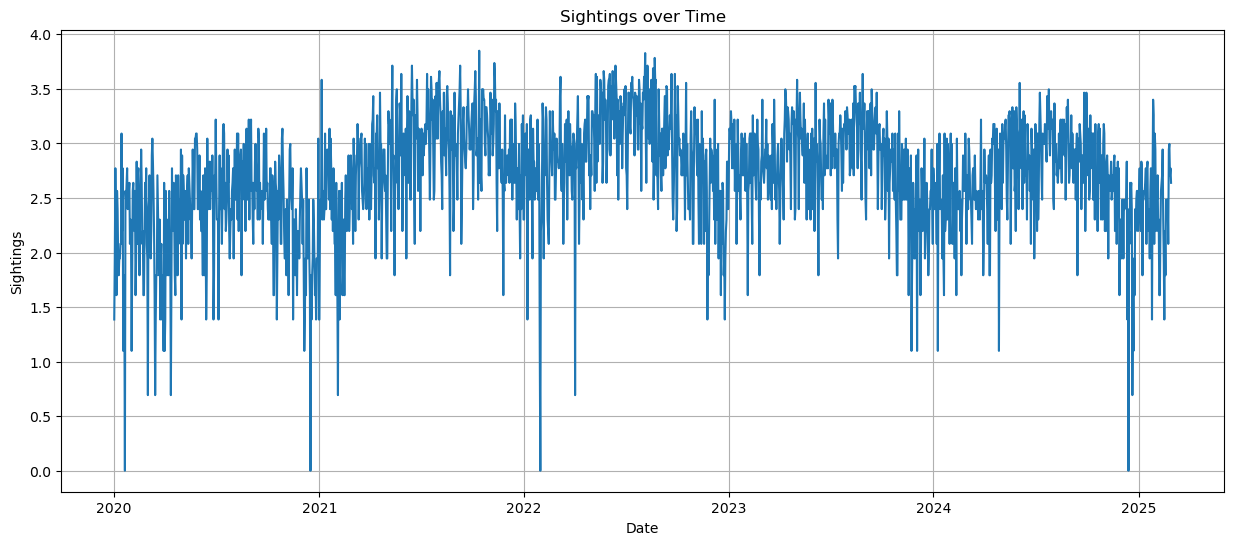

In [53]:
df = rs.copy()

df["ds"] = pd.to_datetime(df["ds"])

plt.figure(figsize=(15,6))
plt.plot(df["ds"], np.log(df["y"]))

plt.xlabel("Date")
plt.ylabel("Sightings")
plt.title("Sightings over Time")
plt.grid(True)

plt.show()

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()

    train = train.dropna(subset=["y"])

    model = NeuralProphet(yearly_seasonality=True, 
                          weekly_seasonality=True, 
                          epochs = 40,
                          accelerator = 'auto',
                          n_lags=7)
    model = model.add_country_holidays(country_name="US")

    model.add_lagged_regressor('apparent_temperature_max', n_lags=12)


    # merge regressors correctly
    # train = train.merge(wd[['ds'] + regressed_features], on="ds", how="left")

    model.fit(train, freq="D", progress="off")

    # build dataframe containing future regressors
    future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test["y"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse, "mape": mape})

neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]
neural_prophet_results_df